In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import psycopg2
from sqlalchemy import create_engine

In [57]:
#Create SQLAlchemy engine
DB_NAME = "nba_data"
DB_USER = "postgres"
DB_PASSWORD = "password"
DB_HOST = "localhost"
DB_PORT = 5432

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

In [58]:
#Sanity check
pd.read_sql("SELECT 1 as ok;", engine)

,ok
0,1


## Load checkpoint datasets (20/40/60) into dataframes

In [60]:
cols = """
season, team_id, team_conference, team_division, made_playoffs,
win_pct_l5, win_pct_l10,
avg_point_diff_l10, avg_pts_l10, avg_tov_l10, avg_reb_l10, avg_ast_l10,
win_pct_s2d, avg_point_diff_s2d
"""

q20 = f"SELECT {cols} FROM team_checkpoint_20;"
q40 = f"SELECT {cols} FROM team_checkpoint_40;"
q60 = f"SELECT {cols} FROM team_checkpoint_60;"

df20 = pd.read_sql(q20, engine)
df40 = pd.read_sql(q40, engine)
df60 = pd.read_sql(q60, engine)

df20.shape, df40.shape, df60.shape

((150, 14), (150, 14), (150, 14))

In [61]:
df40.head()
df40["made_playoffs"].value_counts(dropna=False)


made_playoffs
1    80
0    70
Name: count, dtype: int64

## Target base rate (overall + by conference and division)

In [63]:
# Overall base rate at each checkpoint
def base_rate(df, name):
    rate = df["made_playoffs"].mean()
    n = len(df)
    print(f"{name}: n={n}, playoff_rate={rate:.3f}")

base_rate(df20, "Game 20")
base_rate(df40, "Game 40")
base_rate(df60, "Game 60")

Game 20: n=150, playoff_rate=0.533
Game 40: n=150, playoff_rate=0.533
Game 60: n=150, playoff_rate=0.533


In [64]:
#Overall base rate by conference
(df40.groupby("team_conference")["made_playoffs"]
     .agg(team_seasons="count", playoff_rate="mean")
     .sort_index())

,team_seasons,playoff_rate
team_conference,,
Eastern,75,0.533333
Western,75,0.533333


In [65]:
#Overall base rate by conference + division
conf_div = (df40.groupby(["team_conference","team_division"])["made_playoffs"]
              .mean()
              .reset_index(name="playoff_rate"))
conf_div["playoff_rate_pct"] = (100*conf_div["playoff_rate"]).round(1)
conf_div

,team_conference,team_division,playoff_rate,playoff_rate_pct
0,Eastern,Atlantic,0.64,64.0
1,Eastern,Central,0.56,56.0
2,Eastern,Southeast,0.40,40.0
3,Western,Northwest,0.56,56.0
4,Western,Pacific,0.68,68.0
5,Western,Southwest,0.36,36.0


## Feature Distributions

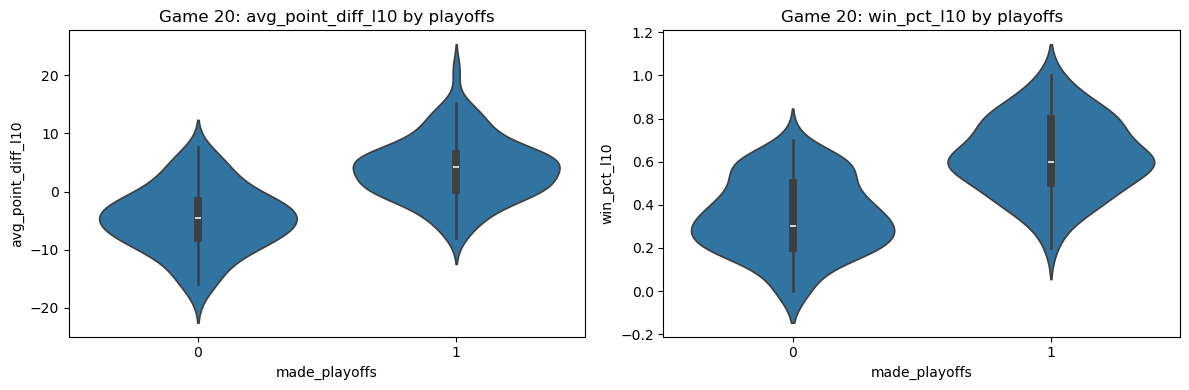

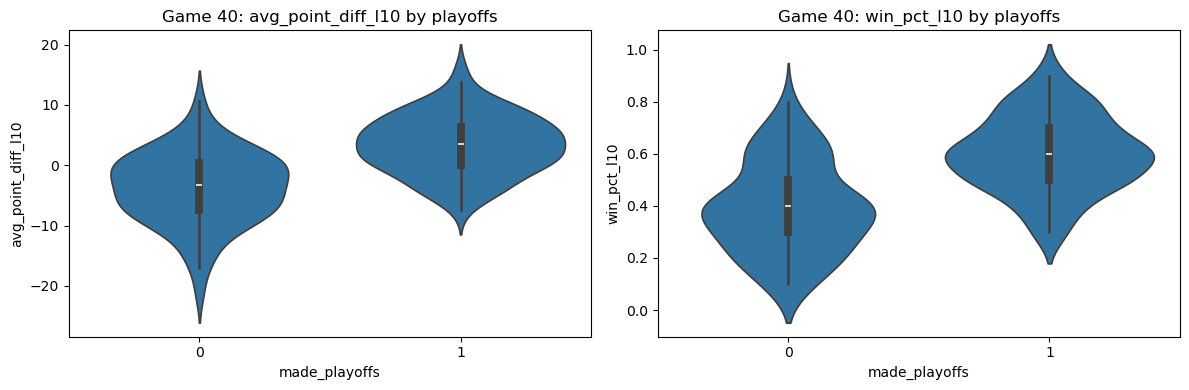

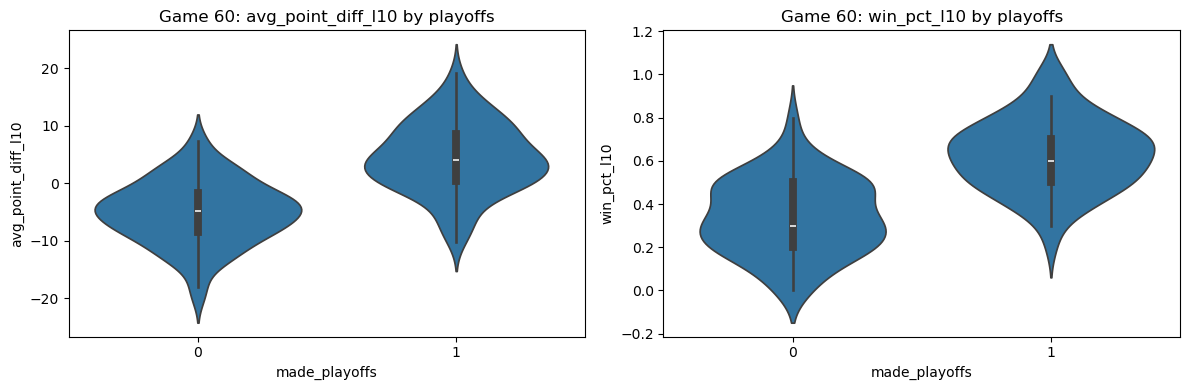

In [67]:
def plot_distributions(df, checkpoint_label):
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    
    sns.violinplot(data=df, x="made_playoffs", y="avg_point_diff_l10", ax=axes[0])
    axes[0].set_title(f"{checkpoint_label}: avg_point_diff_l10 by playoffs")
    axes[0].set_xlabel("made_playoffs")
    
    sns.violinplot(data=df, x="made_playoffs", y="win_pct_l10", ax=axes[1])
    axes[1].set_title(f"{checkpoint_label}: win_pct_l10 by playoffs")
    axes[1].set_xlabel("made_playoffs")
    
    plt.tight_layout()
    plt.show()

plot_distributions(df20, "Game 20")
plot_distributions(df40, "Game 40")
plot_distributions(df60, "Game 60")

The 'average point differential last 10 games' (avg_point_diff_l10) feature is strongly related with playoffs qualification. One interesting point about this feature is that teams that with very high point differentials are a very clear indicator of playoffs qualification, even early in the season. We see this trend become more pronounced as the season progresses, with teams with an average point differential in their last 10 games higher than ~13 are virtually guaranteed a playoffs spot. 

The 'win percentage last 10 games' (win_pct_l10) feature is also strongly indicative of playoffs success, with teams with win percentages around 0.6 and higher typically making the playoffs, and teams with win percentages in the last 10 games around 0.5 or lower typically failing to qualify. 

Likely, these two features will be fairly correlated. 

## Correlation heatmap per checkpoint

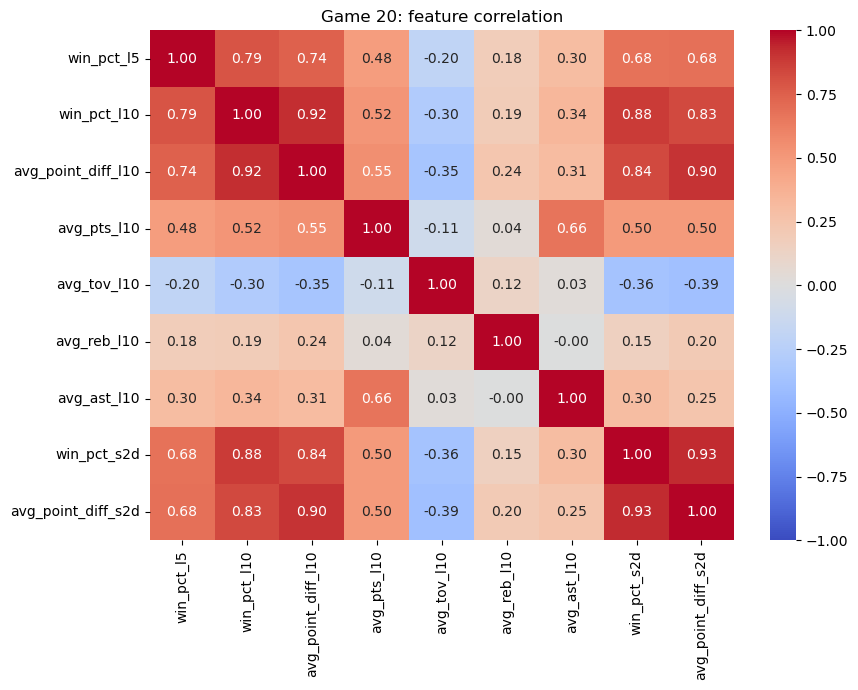

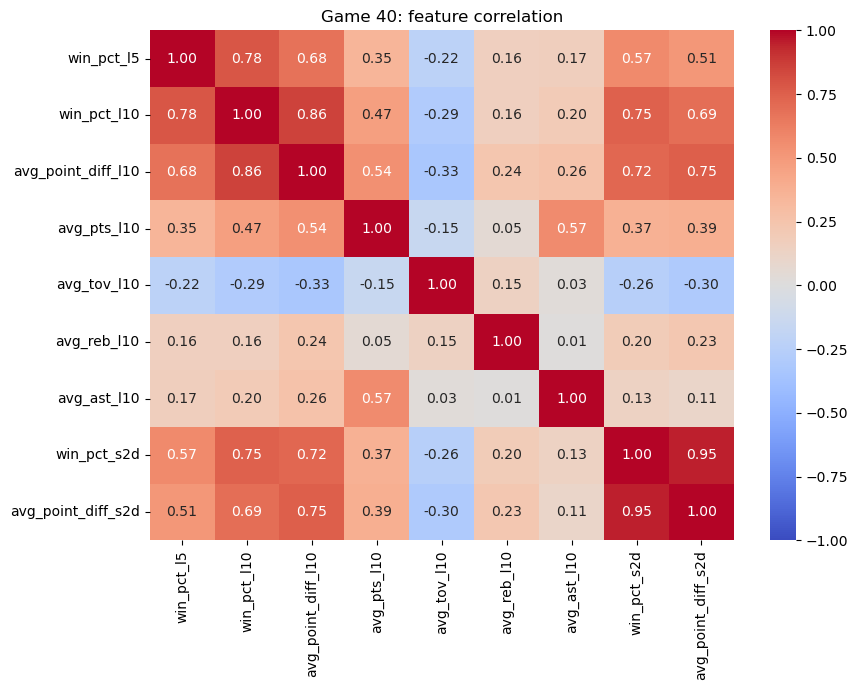

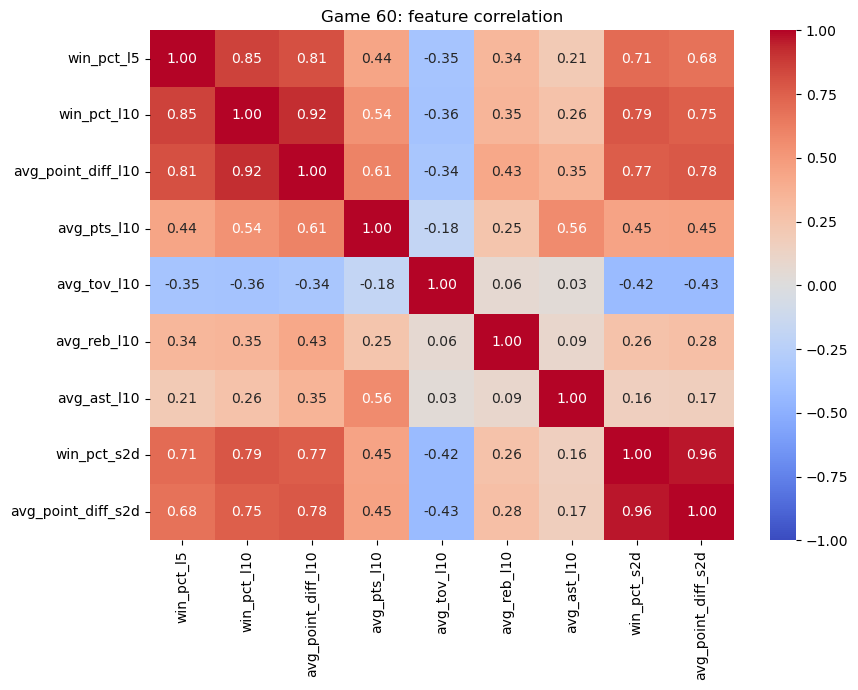

In [69]:
num_cols = [
    "win_pct_l5","win_pct_l10",
    "avg_point_diff_l10","avg_pts_l10","avg_tov_l10","avg_reb_l10","avg_ast_l10",
    "win_pct_s2d","avg_point_diff_s2d"
]

def corr_heatmap(df, checkpoint_label):
    corr = df[num_cols].corr()
    plt.figure(figsize=(9,7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
    plt.title(f"{checkpoint_label}: feature correlation")
    plt.tight_layout()
    plt.show()

corr_heatmap(df20, "Game 20")
corr_heatmap(df40, "Game 40")
corr_heatmap(df60, "Game 60")

In [70]:
def top_corr_pairs(df, top_n=10):
    corr = df[num_cols].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = upper.stack().sort_values(ascending=False).head(top_n)
    return pairs

top_corr_pairs(df40, 10)

win_pct_s2d         avg_point_diff_s2d    0.947265
win_pct_l10         avg_point_diff_l10    0.857592
win_pct_l5          win_pct_l10           0.782880
avg_point_diff_l10  avg_point_diff_s2d    0.751103
win_pct_l10         win_pct_s2d           0.749501
avg_point_diff_l10  win_pct_s2d           0.722272
win_pct_l10         avg_point_diff_s2d    0.688054
win_pct_l5          avg_point_diff_l10    0.679554
                    win_pct_s2d           0.570419
avg_pts_l10         avg_ast_l10           0.567632
dtype: float64

Since 'win_pct_s2d' and 'avg_point_diff_s2d' are extremely correlated (r ≈ 0.95), so these features largely represent the same measure of overall team quality thus far into the season.
'win_pct_l10' and 'avg_point_diff_l10' are similarly well-correlated (r ≈ 0.86). Since both are capturing short-term team performance, point differential tends to be a slightly richer signal than win% alone. 
'win_pct_l5' also correlates highly with 'win_pct_l10' (r ≈ 0.78) since the last 5 games are simply a subset of the last 10, so including both will add limited new information. 

### Modeling Decision

*For Logistic Regression:* To reduce multicollinearity and make coefficients easier to interpret, I will only keep one feature from each of the highly correlated clusters above. I will still use regularization for my Logistic Regression model, however I want to intentionally avoid any near-duplicate predictors. 

*For Random Forest / Gradient Boosting:* Since these models are less sensitive to multicollinearity I can keep a broader set of features, but still will try to avoid any pure duplicates (e.g. win_pct_s2d and avg_point_diff_s2d) in order to reduce noise and make feature importance easier to interpret. 

### Feature Selection 

I will likely keep avg_point_diff_s2d, avg_point_diff_l10 (maybe, will possibly only keep one of these first two), as well as features like win_pct_l5, avg_pts_l10, avg_ast_l10, avg_tov_l10, avg_reb_l10 since these will be less redundant with the with the win/point differential cluster(s). 

## Leakage/timing proof (post- vs. pre-game)

In [83]:
#Use a sample team_id/season for example
from sqlalchemy import text

team_id = 1610612747          # int
season = "2024-25"            # str

q = text("""
SELECT season, team_id, team_game_number, game_date, game_id,
       is_win, point_diff,
       win_pct_l10, avg_point_diff_l10, win_pct_s2d, avg_point_diff_s2d
FROM team_game_training_w_num
WHERE season = :season AND team_id = :team_id
ORDER BY team_game_number
LIMIT 30;
""")

ts = pd.read_sql(q, engine, params={"season": season, "team_id": team_id})
ts.head()

,season,team_id,team_game_number,game_date,game_id,is_win,point_diff,win_pct_l10,avg_point_diff_l10,win_pct_s2d,avg_point_diff_s2d
0,2024-25,1610612747,1,2024-10-22,22400062,1,7,NaN,NaN,NaN,NaN
1,2024-25,1610612747,2,2024-10-25,22400085,1,7,1.00,7.0,1.00,7.0
2,2024-25,1610612747,3,2024-10-26,22400096,1,4,1.00,7.0,1.00,7.0
3,2024-25,1610612747,4,2024-10-28,22400111,0,-4,1.00,6.0,1.00,6.0
4,2024-25,1610612747,5,2024-10-30,22400118,0,-24,0.75,3.5,0.75,3.5


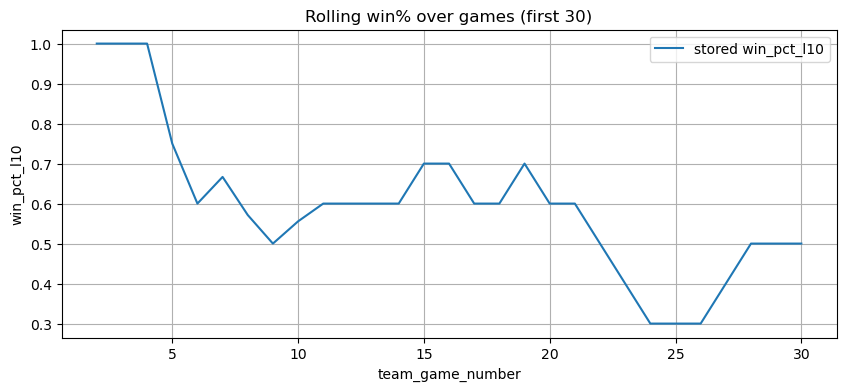

In [85]:
#Plot rolling win% over time
plt.figure(figsize=(10,4))
plt.plot(ts["team_game_number"], ts["win_pct_l10"], label="stored win_pct_l10")
plt.xlabel("team_game_number")
plt.ylabel("win_pct_l10")
plt.title("Rolling win% over games (first 30)")
plt.grid(True)
plt.legend()
plt.show()

In [89]:
#Recompute pre vs post, compare
team_id = 1610612747
season = "2024-25"

q_recalc = f"""
WITH calc AS (
  SELECT
    season, team_id, team_game_number, game_date, game_id,
    win_pct_l10 AS stored_win_pct_l10,

    AVG(CASE WHEN is_win = 1 THEN 1.0 ELSE 0.0 END) OVER (
      PARTITION BY season, team_id
      ORDER BY game_date, game_id
      ROWS BETWEEN 10 PRECEDING AND 1 PRECEDING
    ) AS recomputed_pre,

    AVG(CASE WHEN is_win = 1 THEN 1.0 ELSE 0.0 END) OVER (
      PARTITION BY season, team_id
      ORDER BY game_date, game_id
      ROWS BETWEEN 9 PRECEDING AND CURRENT ROW
    ) AS recomputed_post

  FROM team_game_training_w_num
)
SELECT *
FROM calc
WHERE season = '{season}' AND team_id = {team_id}
ORDER BY team_game_number;
"""
chk = pd.read_sql(q_recalc, engine)
chk.head(15)

,season,team_id,team_game_number,game_date,game_id,stored_win_pct_l10,recomputed_pre,recomputed_post
0,2024-25,1610612747,1,2024-10-22,22400062,NaN,NaN,1.000000
1,2024-25,1610612747,2,2024-10-25,22400085,1.000000,1.000000,1.000000
2,2024-25,1610612747,3,2024-10-26,22400096,1.000000,1.000000,1.000000
3,2024-25,1610612747,4,2024-10-28,22400111,1.000000,1.000000,0.750000
4,2024-25,1610612747,5,2024-10-30,22400118,0.750000,0.750000,0.600000
5,2024-25,1610612747,6,2024-11-01,22400137,0.600000,0.600000,0.666667
6,2024-25,1610612747,7,2024-11-04,22400156,0.666667,0.666667,0.571429
7,2024-25,1610612747,8,2024-11-06,22400174,0.571429,0.571429,0.500000
8,2024-25,1610612747,9,2024-11-08,22400195,0.500000,0.500000,0.555556
9,2024-25,1610612747,10,2024-11-10,22400211,0.555556,0.555556,0.600000


In [91]:
chk["err_pre"] = (chk["stored_win_pct_l10"] - chk["recomputed_pre"]).abs()
chk["err_post"] = (chk["stored_win_pct_l10"] - chk["recomputed_post"]).abs()

chk[["team_game_number","stored_win_pct_l10","recomputed_pre","recomputed_post","err_pre","err_post"]].head(25)
print("Mean abs error pre:", chk["err_pre"].mean())
print("Mean abs error post:", chk["err_post"].mean())

Mean abs error pre: 0.0
Mean abs error post: 0.051028806584362124


This is to confim that the mean abs errore pre = 0.0, so the win_pct_l10 (and other rolling features) use the 10 (or 'n') games *preceding* the current game. E.g. the win_pct_l10 for game 40 will actually be computed from games 30-39. 

I will shift the 20/40/60 checkpoints to actually be at 21/41/61 respectively, so that checkpoint *N* uses features computed from the first N games played, which will be implemented as the pre-game feature row at game *N-1*. 

## Missingness/data quality check

In [93]:
def missingness(df, name):
    miss = (df[num_cols].isna().mean().sort_values(ascending=False) * 100).round(1)
    print(name)
    display(miss[miss > 0])

missingness(df20, "Game 20")
missingness(df40, "Game 40")
missingness(df60, "Game 60")


Game 20


Series([], dtype: float64)

Game 40


Series([], dtype: float64)

Game 60


Series([], dtype: float64)